In this notebook, we will explicitly simulate the time of mutation vs. the
time of selection. Are they associated or decoupled? We will start with 1 sensitive cell, allow it to keep dividing for several generations. During growth, mutations will appear randomly. An antibiotic will be applied at some point, after which stimulus, only resistant cells will survive.

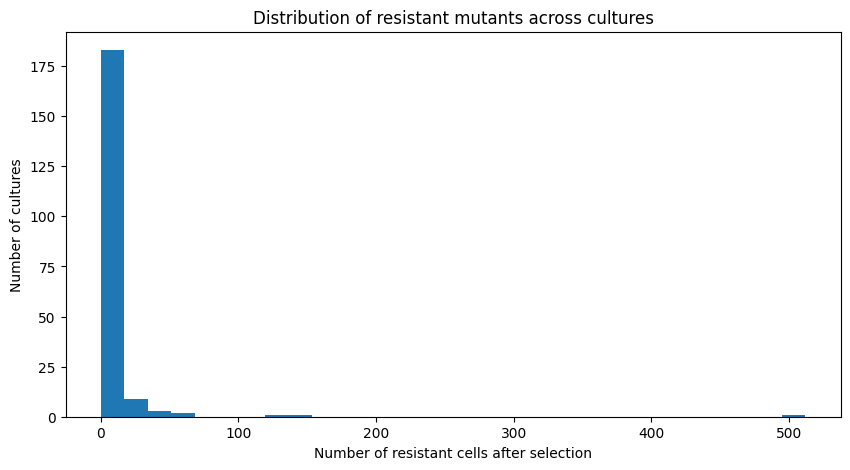

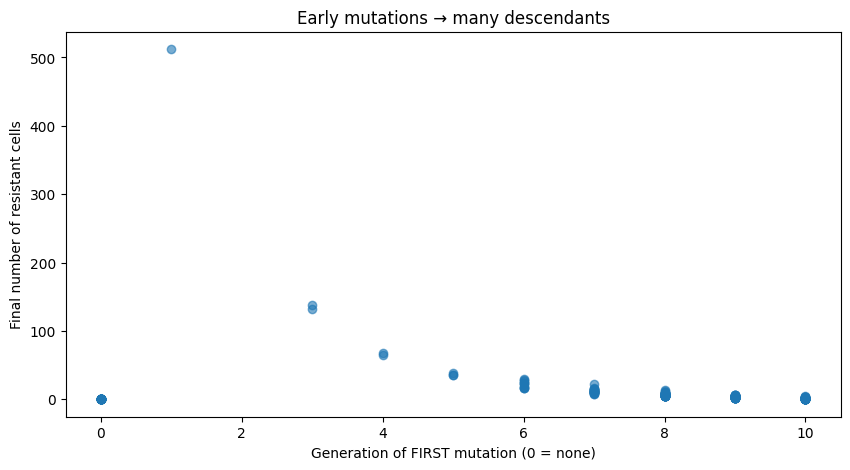

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# PARAMETERS
# -----------------------------
C = 200            # number of cultures
generations = 10   # number of generations before selection
mu = 1e-3          # mutation probability per division
final_population_size = 2**generations  # all cultures reach same size

# -----------------------------
# STORAGE
# -----------------------------
final_mutants = []       # number of resistant cells per culture
first_mutation_time = [] # generation when FIRST mutation occurred

# -----------------------------
# SIMULATION
# -----------------------------
for c in range(C):

    # Start with one non-resistant cell
    population = [(False, 0)]  # False = sensitive, True = resistant
    # Each cell = (is_resistant, birth_generation)

    first_mutation = None

    # Simulate growth BEFORE selection
    for gen in range(1, generations + 1):
        new_population = []

        for is_resistant, birth_gen in population:

            # Each cell divides into two
            for _ in range(2):

                # If already resistant → stays resistant
                if is_resistant:
                    new_population.append((True, gen))

                else:
                    # Mutation can happen during division
                    if np.random.rand() < mu:
                        new_population.append((True, gen))

                        # Record FIRST mutation time
                        if first_mutation is None:
                            first_mutation = gen
                    else:
                        new_population.append((False, gen))

        population = new_population

    # -----------------------------
    # APPLY SELECTION (END ONLY)
    # -----------------------------
    # Only resistant cells survive
    resistant_cells = [cell for cell in population if cell[0]]

    final_mutants.append(len(resistant_cells))

    # If no mutation occurred, mark as None
    first_mutation_time.append(first_mutation)

# -----------------------------
# ANALYSIS
# -----------------------------

# Convert None to a value (e.g., 0) for plotting
mutation_times_numeric = [t if t is not None else 0 for t in first_mutation_time]

# -----------------------------
# PLOT 1: Distribution of mutants
# -----------------------------
plt.figure(figsize=(10,5))
plt.hist(final_mutants, bins=30)
plt.xlabel("Number of resistant cells after selection")
plt.ylabel("Number of cultures")
plt.title("Distribution of resistant mutants across cultures")
plt.show()

# -----------------------------
# PLOT 2: First mutation time vs final mutants
# -----------------------------
plt.figure(figsize=(10,5))
plt.scatter(mutation_times_numeric, final_mutants, alpha=0.6)
plt.xlabel("Generation of FIRST mutation (0 = none)")
plt.ylabel("Final number of resistant cells")
plt.title("Early mutations → many descendants")
plt.show()

Is there a correlation between the mutations and the number of mutants?

In [13]:
np.corrcoef(mutation_times_numeric, final_mutants)

array([[ 1.        , -0.17069435],
       [-0.17069435,  1.        ]])

This next model will reflect mutation at selection (not randomly during growth). In this model, mutations will happen only when selection is applied.

In [14]:
# MODEL 2: MUTATION AT SELECTION
# -----------------------------
lamarck_mutants = []

for c in range(C):

    # No mutations during growth → all cells sensitive
    population_size = final_population_size

    # Mutation happens ONLY at selection
    resistant_count = np.random.binomial(population_size, mu)

    lamarck_mutants.append(resistant_count)


Plot the histograms side-by-side to compare visually.

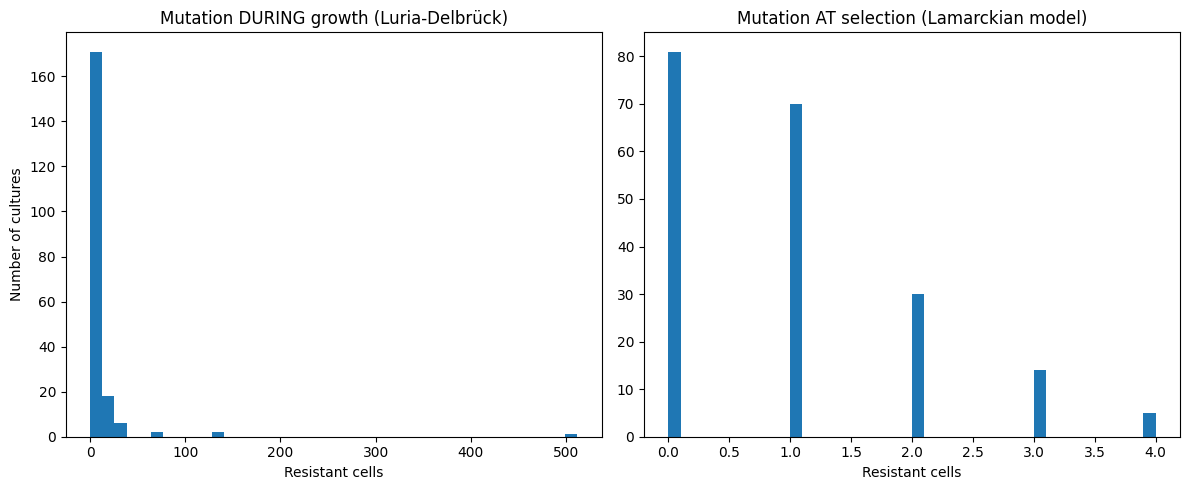

In [15]:
# -----------------------------
# PLOTS
# -----------------------------

# -------- Histogram comparison --------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(final_mutants, bins=40)
plt.title("Mutation DURING growth (Luria-Delbrück)")
plt.xlabel("Resistant cells")
plt.ylabel("Number of cultures")

plt.subplot(1,2,2)
plt.hist(lamarck_mutants, bins=40)
plt.title("Mutation AT selection (Lamarckian model)")
plt.xlabel("Resistant cells")

plt.tight_layout()
plt.show()

# -------- Scatter: timing matters --------
# Convert None → 0
mutation_times = [t if t is not None else 0 for t in mutation_times_numeric]

Print the variances:

In [16]:
print("LD variance:", np.var(final_mutants))
print("Lamarck variance:", np.var(lamarck_mutants))

LD variance: 1513.8956
Lamarck variance: 1.0584


Print both means and variances for both models (for convenience):

In [17]:
print("LD mean:",np.mean(final_mutants), "LD variance:", np.var(final_mutants))
print("Lamarck mean:",np.mean(lamarck_mutants), "Lamarck variance:", np.var(lamarck_mutants))

LD mean: 10.12 LD variance: 1513.8956
Lamarck mean: 0.96 Lamarck variance: 1.0584


Answer the following questions:
1. Describe the differences between the two distributions.
> The LD mutation distribution is much more randomas compared to the Lamarck distribution. There area also a number of plates containing large (‘jackpot’) numbers of resistant cells, which isn’t seen in the Lamarck model.
2. Do cultures look similar to each other within each model?
> Overall, most cultures look similar. The vast majority of cultures have small numbers of resistant cells; the biggest differences are the presence of ‘jackpot’ plates in the LD distribution, while the Lamarck cultures are relatively consistent.
3. Which model better explains the biological data observed by Luria Delbruck?
> Fittingly, the LD model explains Luria Delbruck’s biological data. This is a more accurate model of how mutations arise spontaneously in biology, rather than in an induced model like Lamarck.
4. Look at the scatterplot of first mutation time vs final mutants. What pattern do you observe?
> Earlier time of first mutation tends to correlate with higher numbers of mutants at selection. This makes sense, as these mutants have a longer period of time to divide.
5. Compare mean and variance in both models.
> The mean is very similar in both models (possibly within one order of magnitude) but the variance for LD  is much higher than the Lamarck variance, which is clearly reflected in the side-by-side distributions. Also, the mean and variance for the Lamarck model are the same, whereas the variance vastly exceeds the mean in the LD distribution.